# Report Assets. Hero Sequence and Analysis Charts

Notebook ini menghasilkan aset visual untuk proposal dan video pitching, yaitu transformasi satu sampel foto mata melalui setiap tahap pipeline, serta salinan chart analisis resolusi tinggi. Tahap atensi CSA sengaja tidak ditampilkan sebagai peta atensi karena CSA pada pipeline produksi belum benar-benar terlatih (lihat `docs/MODEL_ARCHITECTURE_CONJUNCTIVA.md`), digantikan heatmap biomarker warna Path A yang memang valid dan teruji.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import albumentations as A
from albumentations.pytorch import ToTensorV2

from configs import paths
from src.common import eval as evaluation
from src.common import features, manifest as manifest_utils, qc, preprocess, train
from src.common.models import HemavisionModel
from src.sites.conjunctiva import data, segmentation

output_dir = paths.outputs_dir("conjunctiva")
artifact_dir = paths.artifacts_dir("conjunctiva")

assets_root = paths.HEMAVISION_ROOT / "assets" / "conjunctiva"
hero_dir = assets_root / "hero_sequence"
chart_dir = assets_root / "analysis_charts"
hero_dir.mkdir(parents=True, exist_ok=True)
chart_dir.mkdir(parents=True, exist_ok=True)

manifest = manifest_utils.assign_kfold(data.build_manifest(save=False), n_splits=5, seed=42)
qc_report = pd.read_csv(output_dir / "qc_report.csv")
handcrafted = pd.read_csv(output_dir / "handcrafted_features.csv")
embeddings_resnet18 = np.load(output_dir / "deep_embeddings.npy")
embedding_uids_resnet18 = pd.read_csv(output_dir / "deep_embeddings_uids.csv")["uid"].tolist()
with open(output_dir / "multitask_optuna_best_params.json") as handle:
    best_params = json.load(handle)["best_params"]

print("device", "cuda" if torch.cuda.is_available() else "cpu")

Eyes-Defy Italy melewati 2 folder tanpa metadata atau file lengkap: [93, 95]
Eyes-Defy India melewati 1 folder tanpa metadata atau file lengkap: [7]
device cuda


## Pick Sample

Sampel dipilih dari Eyes-Defy karena memiliki foto mata utuh, dan dipastikan lolos quality control agar representatif.

In [2]:
candidates = qc_report[(qc_report["dataset"] == "eyes_defy") & (qc_report["passed"])]["uid"]
sample_uid = candidates.iloc[0]
sample_row = manifest[manifest["uid"] == sample_uid].iloc[0]
print("sample uid", sample_uid)
print("hb_gdl", sample_row["hb_gdl"], "anemic", sample_row["anemic"], "site", sample_row["site"])

sample uid italy_001
hb_gdl 9.3 anemic 1 site italy


## Stage 1. Raw Eye Photo

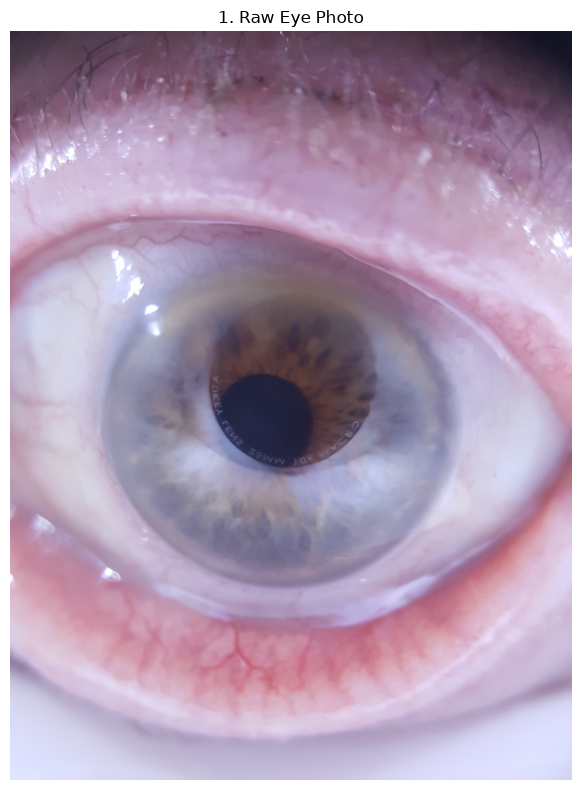

In [3]:
raw_rgb = segmentation.load_raw_rgb(sample_row["raw_path"])

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(raw_rgb)
ax.set_title("1. Raw Eye Photo")
ax.axis("off")
plt.tight_layout()
plt.savefig(hero_dir / "01_raw.png", dpi=150)
plt.show()

## Stage 2. Quality Control Gate

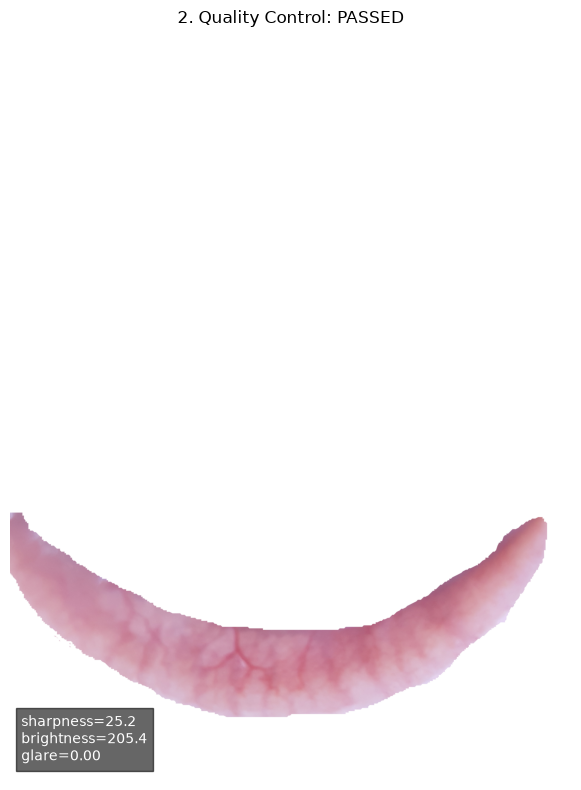

In [4]:
qc_result = qc.quality_check(sample_row["roi_path"])
roi_rgb, roi_mask = qc.load_roi(sample_row["roi_path"])

status = "PASSED" if qc_result["passed"] else f"REJECTED ({qc_result['reasons']})"
fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(roi_rgb)
ax.axis("off")
ax.set_title(f"2. Quality Control: {status}")
info = (
    f"sharpness={qc_result['laplacian_variance']:.1f}\n"
    f"brightness={qc_result['brightness']:.1f}\n"
    f"glare={qc_result['glare_fraction']:.2f}"
)
ax.text(0.02, 0.02, info, transform=ax.transAxes, color="white", fontsize=10,
        bbox=dict(facecolor="black", alpha=0.6), verticalalignment="bottom")
plt.tight_layout()
plt.savefig(hero_dir / "02_qc.png", dpi=150)
plt.show()

## Stage 3. Conjunctiva Segmentation

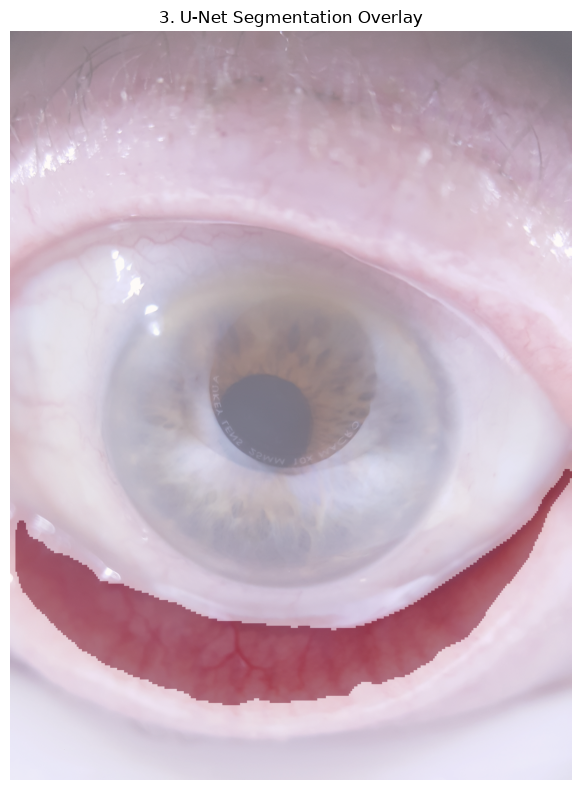

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
segmentation_model = segmentation.build_model()
segmentation_model.load_state_dict(torch.load(artifact_dir / "segmentation_unet.pt", map_location=device))
segmentation_model = segmentation_model.to(device)
segmentation_model.eval()

inference_transform = A.Compose([
    A.Resize(320, 320),
    A.Normalize(mean=segmentation.IMAGENET_MEAN, std=segmentation.IMAGENET_STD),
    ToTensorV2(),
])
transformed = inference_transform(image=raw_rgb)
with torch.no_grad():
    logits = segmentation_model(transformed["image"].unsqueeze(0).to(device))
    predicted_mask = (torch.sigmoid(logits)[0, 0].cpu().numpy() > 0.5)

mask_upscaled = cv2.resize(
    predicted_mask.astype(np.uint8), (raw_rgb.shape[1], raw_rgb.shape[0]), interpolation=cv2.INTER_NEAREST
)

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(raw_rgb)
ax.imshow(mask_upscaled, cmap="Reds", alpha=0.4)
ax.set_title("3. U-Net Segmentation Overlay")
ax.axis("off")
plt.tight_layout()
plt.savefig(hero_dir / "03_segmentation.png", dpi=150)
plt.show()

## Stage 4. Illumination Normalization

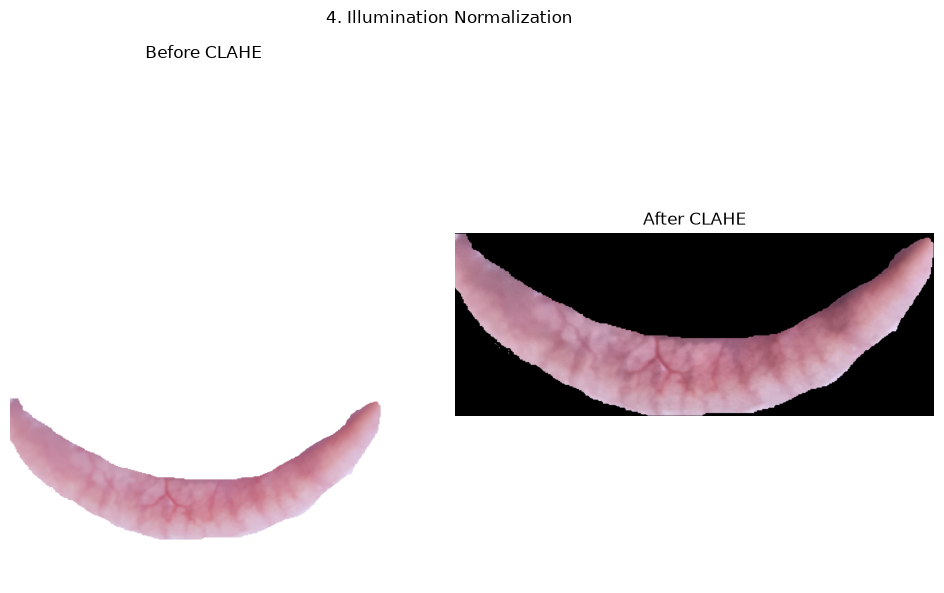

In [6]:
normalized = preprocess.normalize_roi(sample_row["roi_path"])

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(roi_rgb)
axes[0].set_title("Before CLAHE")
axes[1].imshow(normalized["rgb"])
axes[1].set_title("After CLAHE")
for ax in axes:
    ax.axis("off")
plt.suptitle("4. Illumination Normalization")
plt.tight_layout()
plt.savefig(hero_dir / "04_clahe_before_after.png", dpi=150)
plt.show()

## Stage 5. Color Biomarker Heatmap

Peta ini memakai kanal a* CIELAB (derajat kemerahan) per pixel, bukan atensi neural network, sehingga bermakna dan valid: nilai a* yang lebih tinggi berkorelasi dengan kadar hemoglobin yang lebih tinggi (lihat Stage 4 notebook).

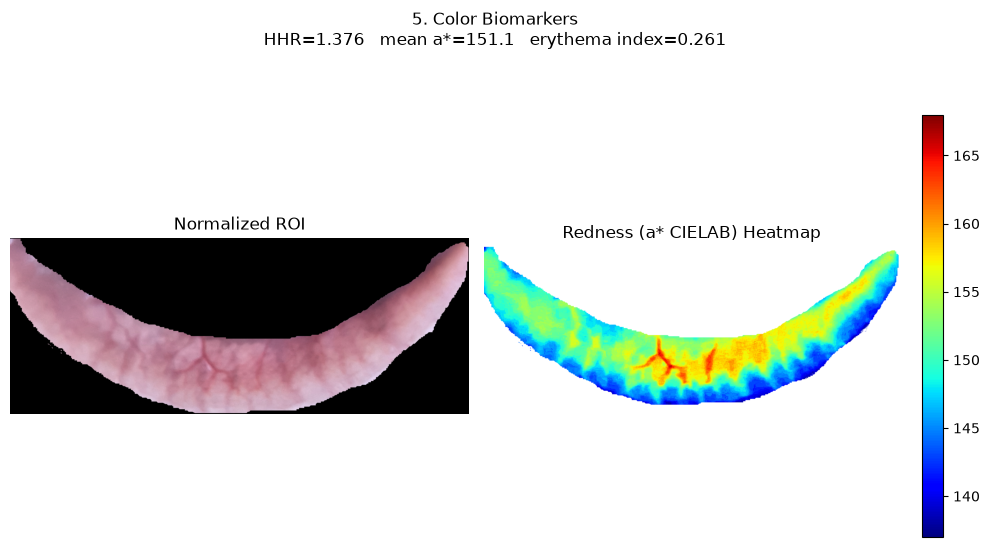

In [7]:
handcrafted_values = features.compute_handcrafted_features(normalized["rgb"], normalized["valid_mask"])
lab = cv2.cvtColor(normalized["rgb"], cv2.COLOR_RGB2LAB).astype(np.float32)
redness_map = np.where(normalized["valid_mask"], lab[:, :, 1], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(normalized["rgb"])
axes[0].set_title("Normalized ROI")
heatmap = axes[1].imshow(redness_map, cmap="jet")
axes[1].set_title("Redness (a* CIELAB) Heatmap")
fig.colorbar(heatmap, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.axis("off")
info = (
    f"HHR={handcrafted_values['hhr']:.3f}   "
    f"mean a*={handcrafted_values['mean_a']:.1f}   "
    f"erythema index={handcrafted_values['erythema_index']:.3f}"
)
plt.suptitle(f"5. Color Biomarkers\n{info}")
plt.tight_layout()
plt.savefig(hero_dir / "05_biomarker_heatmap.png", dpi=150)
plt.show()

## Stage 6. Final Prediction Card

Prediksi memakai model tuned Full Fusion ResNet18-CSA fold pertama, konsisten dengan model final yang tersimpan di Stage 5.

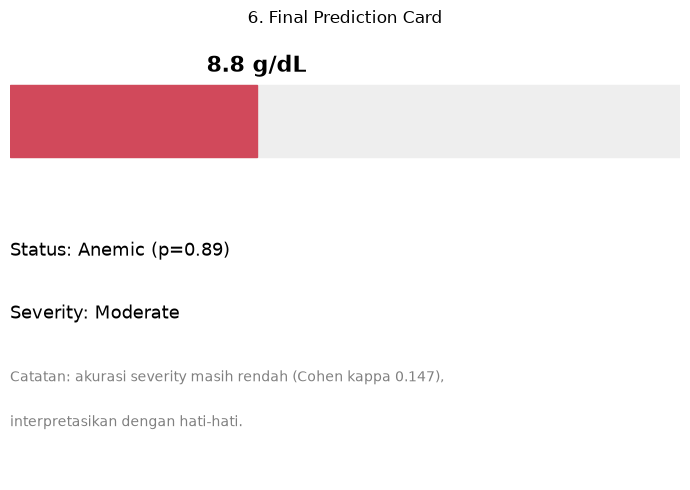

predicted_hb 8.831343650817871 true hb 9.3


In [8]:
site_categories = sorted(manifest["site"].unique().tolist())
stats = features.compute_fusion_stats(handcrafted, manifest, site_categories=site_categories)
sample_manifest = manifest[manifest["uid"] == sample_uid]
sample_embedding = embeddings_resnet18[embedding_uids_resnet18.index(sample_uid)][None, :]

fusion_vector = features.build_fusion_input(
    handcrafted, sample_embedding, sample_manifest, stats=stats, use_handcrafted=True, use_deep=True,
)

final_model = HemavisionModel(
    input_dim=fusion_vector.shape[1], attention_dim=best_params["attention_dim"],
    trunk_dim=best_params["trunk_dim"], dropout=best_params["dropout"],
)
final_model.load_state_dict(
    torch.load(artifact_dir / "multitask_full_fusion_resnet18_tuned_fold0.pt", map_location="cpu")
)
final_model.eval()
with torch.no_grad():
    outputs = final_model(torch.tensor(fusion_vector, dtype=torch.float32))
    predicted_hb = float(outputs["expected_hb"][0])
    anemic_probability = float(torch.softmax(outputs["classification_logits"], dim=1)[0, 1])
    severity_index = int(torch.sigmoid(outputs["severity_logits"])[0].gt(0.5).sum())

from src.common.models import SEVERITY_ORDER
severity_label = SEVERITY_ORDER[severity_index]
anemic_label = "Anemic" if anemic_probability >= 0.5 else "Non-Anemic"

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlim(0, 24)
ax.set_ylim(0, 1)
ax.axis("off")

bar_bottom, bar_height = 0.72, 0.16
ax.add_patch(plt.Rectangle((0, bar_bottom), 24, bar_height, color="#eeeeee"))
ax.add_patch(plt.Rectangle((0, bar_bottom), predicted_hb, bar_height, color="#d1495b"))
ax.text(predicted_hb, bar_bottom + bar_height + 0.03, f"{predicted_hb:.1f} g/dL",
        ha="center", fontsize=16, fontweight="bold")

ax.text(0, 0.5, f"Status: {anemic_label} (p={anemic_probability:.2f})", fontsize=13)
ax.text(0, 0.36, f"Severity: {severity_label}", fontsize=13)
ax.text(0, 0.22, "Catatan: akurasi severity masih rendah (Cohen kappa 0.147),",
        fontsize=10, color="grey")
ax.text(0, 0.12, "interpretasikan dengan hati-hati.", fontsize=10, color="grey")

ax.set_title("6. Final Prediction Card")
plt.tight_layout()
plt.savefig(hero_dir / "06_output_card.png", dpi=150)
plt.show()

print("predicted_hb", predicted_hb, "true hb", sample_row["hb_gdl"])

## Analysis Charts (Standalone Export)

Salinan resolusi tinggi dari chart analisis utama, siap dipakai langsung di slide proposal.

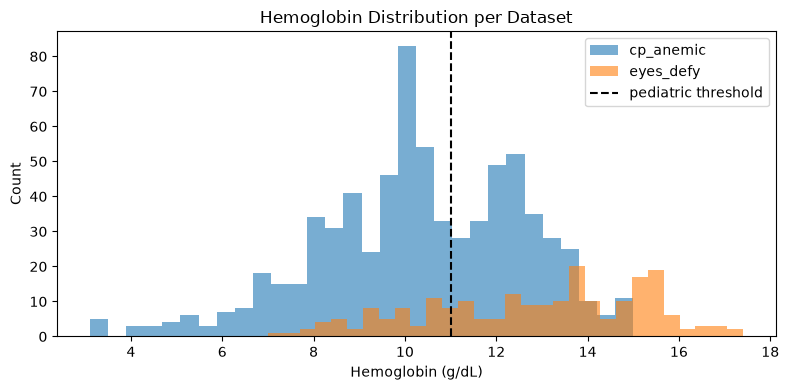

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, group in manifest.groupby("dataset"):
    ax.hist(group["hb_gdl"].dropna(), bins=30, alpha=0.6, label=name)
ax.axvline(11.0, color="black", linestyle="--", label="pediatric threshold")
ax.set_xlabel("Hemoglobin (g/dL)")
ax.set_ylabel("Count")
ax.set_title("Hemoglobin Distribution per Dataset")
ax.legend()
plt.tight_layout()
plt.savefig(chart_dir / "hb_distribution.png", dpi=150)
plt.show()

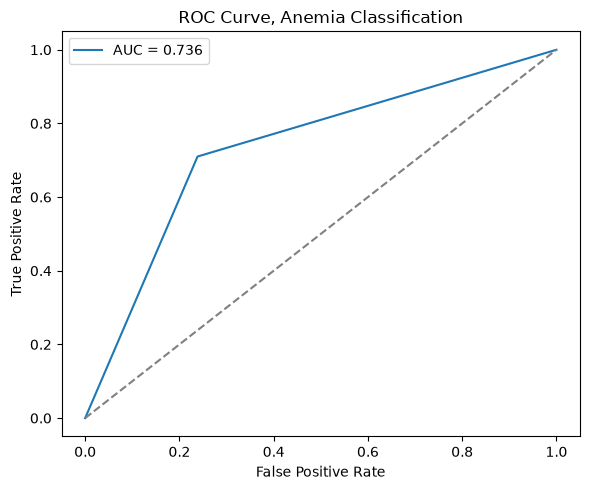

In [10]:
from sklearn.metrics import roc_curve, auc

oof_tuned = pd.read_csv(output_dir / "multitask_oof_full_fusion_resnet18_csa_tuned.csv")
false_positive_rate, true_positive_rate, _ = roc_curve(oof_tuned["anemic_true"], oof_tuned["anemic_pred"])
roc_auc = auc(false_positive_rate, true_positive_rate)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(false_positive_rate, true_positive_rate, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve, Anemia Classification")
ax.legend()
plt.tight_layout()
plt.savefig(chart_dir / "roc_curve.png", dpi=150)
plt.show()

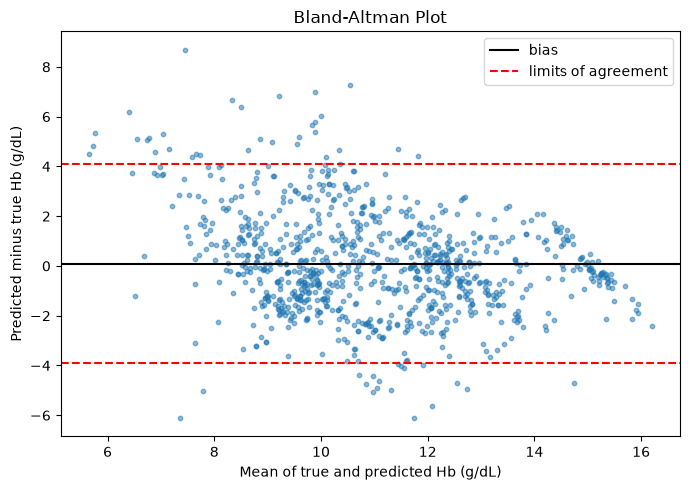

In [11]:
bland_altman = evaluation.bland_altman_stats(oof_tuned["hb_true"], oof_tuned["hb_pred"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bland_altman["mean_value"], bland_altman["difference"], s=10, alpha=0.5)
ax.axhline(bland_altman["bias"], color="black", label="bias")
ax.axhline(bland_altman["lower_limit"], color="red", linestyle="--", label="limits of agreement")
ax.axhline(bland_altman["upper_limit"], color="red", linestyle="--")
ax.set_xlabel("Mean of true and predicted Hb (g/dL)")
ax.set_ylabel("Predicted minus true Hb (g/dL)")
ax.set_title("Bland-Altman Plot")
ax.legend()
plt.tight_layout()
plt.savefig(chart_dir / "bland_altman.png", dpi=150)
plt.show()

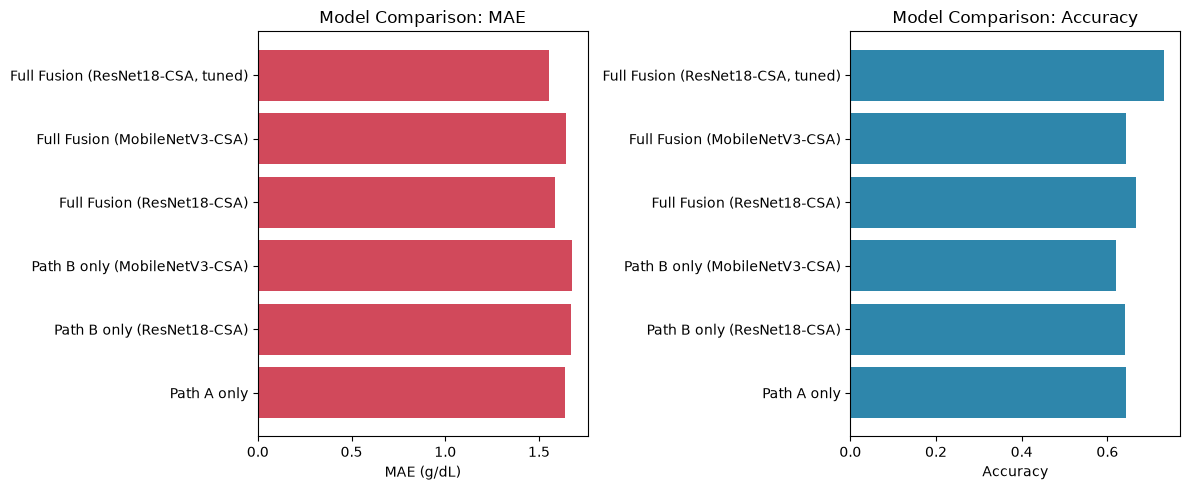

semua asset tersimpan di /home/praktikan/projects/Azril/hemavision/assets/conjunctiva/hero_sequence dan /home/praktikan/projects/Azril/hemavision/assets/conjunctiva/analysis_charts


In [12]:
comparison_table = pd.read_csv(output_dir / "multitask_model_comparison.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(comparison_table["configuration"], comparison_table["mae_mean"], color="#d1495b")
axes[0].set_xlabel("MAE (g/dL)")
axes[0].set_title("Model Comparison: MAE")
axes[1].barh(comparison_table["configuration"], comparison_table["accuracy_mean"], color="#2e86ab")
axes[1].set_xlabel("Accuracy")
axes[1].set_title("Model Comparison: Accuracy")
plt.tight_layout()
plt.savefig(chart_dir / "model_comparison.png", dpi=150)
plt.show()

print("semua asset tersimpan di", hero_dir, "dan", chart_dir)